In [1]:
import sys
import os
from pathlib import Path

# Robustly find the project root
current_dir = Path(os.getcwd()).resolve()
project_root = None

# Walk up until we find 'models'
d = current_dir
for _ in range(5):
    if (d / "models").exists() and (d / "simulations").exists():
        project_root = d
        break
    if d.parent == d:
        break
    d = d.parent

if project_root:
    src_path = str(project_root)
    if str(project_root) not in sys.path:
        sys.path.append(str(project_root))
    print(f"Project root found at: {project_root}")
else:
    print("Warning: Project root not found automatically. Using absolute fallback.")
    # Fallback to strict relative path just in case
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '')))


Project root found at: /Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/e_network_inequality


# Basic Testing (Vectorized)

In this notebook we test that the vectorized files work well and produce similar results to the original model.

## Setup

In [2]:
from utils.imports import *
from models.vectorized_model import VectorizedModel
import matplotlib.pyplot as plt

/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Save and load pud_final as JSON
import json
from networkx.readwrite import json_graph
from pathlib import Path

JSON_PATH = Path("../../networks/citation_data/pud_final.json")

# Save to JSON
def save_network_json(G, path):
    data = json_graph.node_link_data(G)
    with open(path, "w") as f:
        json.dump(data, f)
    print(f"Saved network to {path}")

# Load from JSON
def load_network_json(path):
    with open(path, "r") as f:
        data = json.load(f)
    # Fix for networkx expecting 'edges' instead of 'links' or vice-versa
    if "links" in data and "edges" not in data:
        data["edges"] = data["links"]
    G = json_graph.node_link_graph(data)
    print(f"Loaded network from {path}")
    return G

# Example usage:
# save_network_json(pud_final, JSON_PATH)
my_network = load_network_json(JSON_PATH)

Loaded network from ../../networks/citation_data/pud_final.json


/Users/ignacio/Documents/VS Code/GitHub Repositories/e_network_inequality/.venv/lib/python3.10/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


In [4]:
# n_agents = 1000
# my_network = nx.gnp_random_graph(n_agents, p=0.1, directed=True) #nx.complete_graph(n_agents, create_using=nx.DiGraph())

## Try with Bayes Agent (Vectorized)

In [5]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='bayes')
my_model.run_simulation(number_of_steps=50000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)
print('conclusion core', my_model.conclusion_core)

df_bayes = pd.DataFrame(my_model.credences_history).T
df_bayes.head(3)

100%|██████████| 50000/50000 [00:12<00:00, 3973.85it/s]


steps:  50000
conclusion:  0.6091954022988506
conclusion core 0.8205128205128205


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,0.569148,0.070688,0.457732,0.643927,0.588072,0.460801,0.941542,0.726088,0.219625,0.099115,...,0.555200,0.669872,0.276607,0.032891,0.570147,0.049445,0.970731,0.243644,0.35317,0.899361
1,0.569148,0.070688,0.459718,0.647587,0.590008,0.460801,0.941981,0.727677,0.222380,0.099115,...,0.555200,0.671639,0.279820,0.032638,0.576019,0.049445,0.970503,0.245122,0.35317,0.900083
2,0.563253,0.070688,0.459718,0.645760,0.584190,0.460801,0.941981,0.727677,0.220999,0.099115,...,0.553223,0.666324,0.278211,0.032638,0.574064,0.049445,0.970731,0.245122,0.35317,0.898634


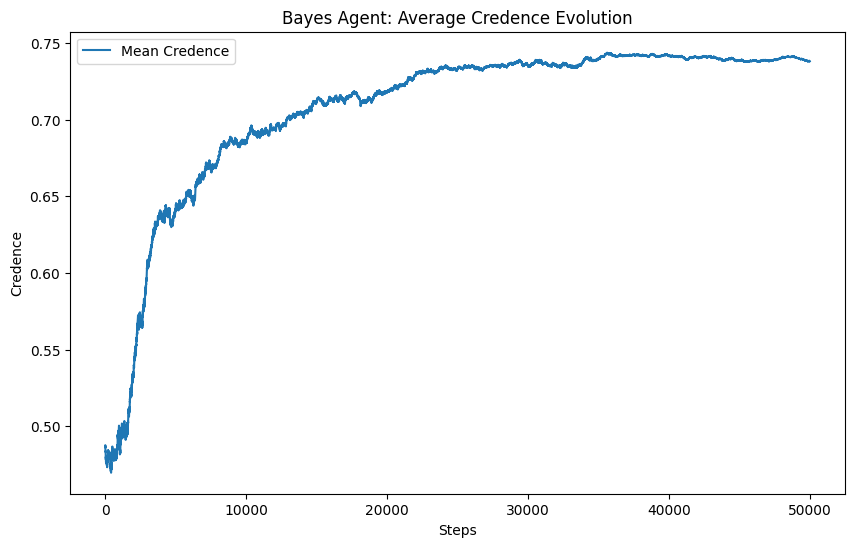

In [6]:
# Plot mean credence for Bayes
# Credences are 1D arrays (scalar per agent)
mean_credence = df_bayes.mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(mean_credence, label='Mean Credence')
plt.title('Bayes Agent: Average Credence Evolution')
plt.xlabel('Steps')
plt.ylabel('Credence')
plt.legend()
plt.show()

## Try with Beta Agent (Vectorized)

In [7]:
seed=420
my_model = VectorizedModel(my_network, n_experiments=10, uncertainty=0.001,
                 histories=True,sampling_update=True,
                 seed=seed,seeded=False, agent_type='beta')

my_model.run_simulation(number_of_steps=10000,show_bar=True)
print('steps: ',my_model.n_steps)
print('conclusion: ',my_model.conclusion)

# agent_histories in VectorizedModel is a list of lists of numpy arrays
df = pd.DataFrame(my_model.credences_history).T # Transpose because history[agent] is list of steps
df.head(3)

 82%|████████▏ | 8150/10000 [00:03<00:00, 2369.91it/s]


steps:  8151
conclusion:  0.6896551724137931


,0,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,"[0.9070066462290652, 0.8120171836469225]","[0.4406544696924886, 0.5327214110285678]","[0.9999991164874256, 0.9384616648633718]","[0.22753371423918978, 0.633093748990963]","[0.9999993866228071, 0.4421874399547612]","[0.6090610003585726, 0.05487507426584477]","[0.7288073477644049, 0.7738040694717244]","[0.7205877973259267, 0.8891765987853221]","[0.14996664708753263, 0.2866124671801049]","[0.3277455149486602, 0.01755133941827776]",...,"[1.2107819604302085e-07, 0.6296340658762849]","[0.0426246602543638, 0.5432083717159615]","[0.5178968885138673, 0.675867490527616]","[0.7166492627740667, 0.8885839434529543]","[5.6023733052145195e-06, 0.5212443302509456]","[0.5621314400836752, 0.367416609908038]","[0.4710695411605556, 0.005001308943777384]","[0.3523855689977631, 0.6839673309052482]","[0.6941663582140991, 0.950078955077986]","[0.46601820269091476, 0.3379142817345784]"
1,"[0.7184691091252426, 0.8909427820882522]","[0.6240606520499996, 0.41389377218374734]","[0.413813431959503, 0.3072544927258904]","[0.35664464279081776, 0.5632509330142645]","[0.5133158718496474, 0.41483542392434986]","[0.16720203658884153, 0.42488015763176473]","[0.35317118541201953, 0.5117304044748874]","[0.34901087407011505, 0.5626559832179984]","[0.7166477162575855, 0.6593105736654895]","[0.25442005116084676, 0.00036362820591640313]",...,"[0.2568456090042157, 0.5301950926802813]","[0.30969471975894475, 0.41722041034284835]","[0.46174857564975297, 0.6025767555412898]","[0.17823890661556663, 0.5744373812816549]","[0.11934814998296668, 0.40763781579284764]","[0.6634566231173256, 0.519239411450933]","[0.6078733319221583, 0.5966588023624887]","[0.45692965482218717, 0.47339972155548826]","[0.25747477031427896, 0.2504689841270755]","[0.37031252058544056, 0.6087151385418889]"
2,"[0.5056085973836745, 0.6294624149059613]","[0.7672027457571673, 0.6308929004080354]","[0.3797618192268446, 0.4632342308053327]","[0.34251145060650423, 0.5400433078581919]","[0.4146104781432344, 0.29577144709063347]","[0.4378782214117666, 0.45507335996996]","[0.2692758579130226, 0.6590380967935713]","[0.44880363143952823, 0.3304950598520334]","[0.6180899670665815, 0.45615837085628425]","[0.3551388619256518, 0.02390241549059364]",...,"[0.38819458165648757, 0.618862609544383]","[0.3582809408712864, 0.47457320296077166]","[0.31733720676548255, 0.5464481859527687]","[0.4365603964512773, 0.566197984041081]","[0.00047060311892434915, 0.5233581411942757]","[0.5949457695006063, 0.34409083471242213]","[0.7090281759172755, 0.4088416775576514]","[0.48690870414330994, 0.35697807311757246]","[0.4043850905656006, 0.43759518120971524]","[0.4456291101654797, 0.5660901355822161]"


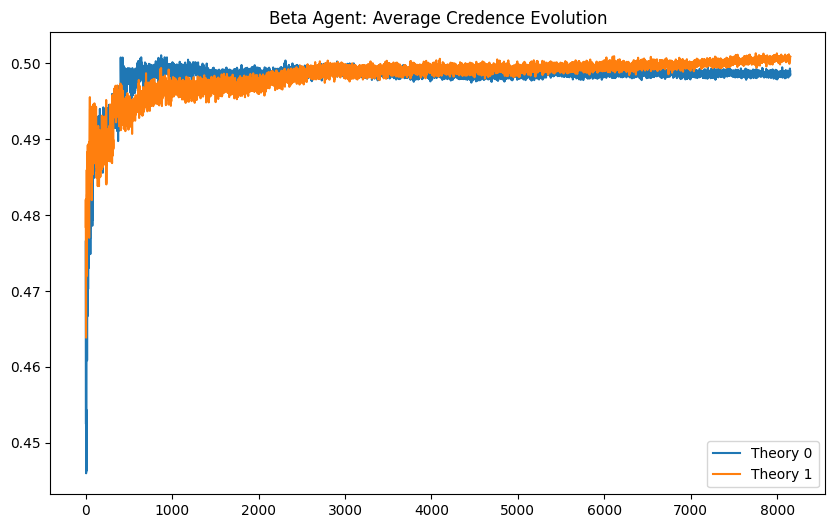

In [8]:
# Extract the first coordinate (x) for each pair and calculate column-wise mean
# In vectorized model, credences are stored as arrays [c0, c1].
x_means = df.map(lambda pair: pair[0]).mean(axis=1)
y_means = df.map(lambda pair: pair[1]).mean(axis=1)
plt.figure(figsize=(10, 6))
plt.plot(x_means, label='Theory 0')
plt.plot(y_means, label='Theory 1')
plt.title('Beta Agent: Average Credence Evolution')
plt.legend()
plt.show()

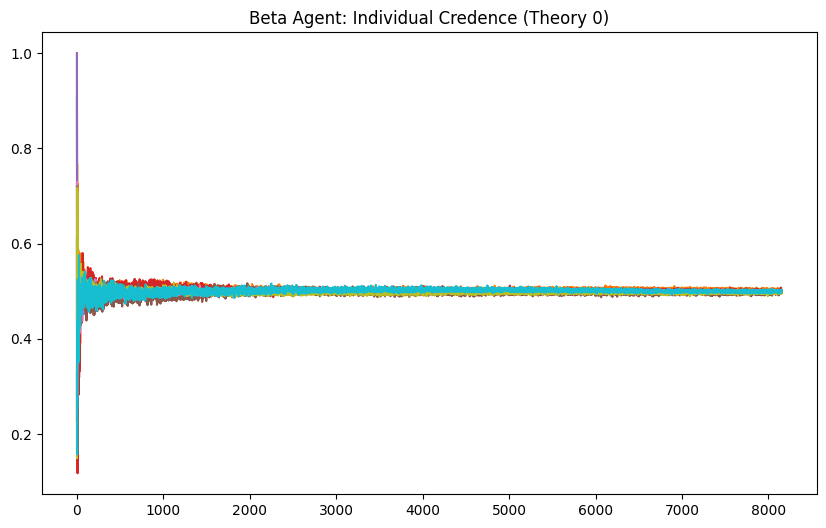

In [9]:
# Extract the first coordinate (x) for each pair
x_values = df.map(lambda pair: pair[0])

# Plot the first coordinate for each row (agent)
plt.figure(figsize=(10, 6))
# Plot a subset of agents to avoid clutter if N is large
for agent_idx in range(min(10, x_values.shape[1])):
    plt.plot(x_values[agent_idx], label=f'Agent {agent_idx}')
plt.title('Beta Agent: Individual Credence (Theory 0)')
plt.show()